<div style="text-align: center;">

<h1>E-Commerce Delivery Prediction</h1>

<h3>Predicting Whether an Order Will Be Delivered on Time or Not</h3>

<p><b>An End-to-End Data Science & Machine Learning Project</b></p>

</div>

## 1. Business Problem

E-commerce companies handle a large number of orders every day. Delayed deliveries can lead to customer dissatisfaction, complaints, and loss of customer trust.

The aim of this project is to analyze historical e-commerce order and shipping data and build a machine learning model that can **predict whether an order will be delivered on time or not**.

### Project Objective

* Analyze historical e-commerce order and delivery data.
* Identify factors associated with delivery outcomes.
* Prepare the data for machine learning.
* Build a classification model to predict whether an order will be delivered on time or not.
* Evaluate the performance of the model.
* Generate useful insights that can help improve delivery operations.

### Business Question

**"Can we predict whether an e-commerce order will be delivered on time or not, based on customer, product, and shipment-related information?"**


## Step 1: Import Necessary Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Data


In [5]:
# Load the dataset
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\E_Commerce.xlsx")



# Step 3: Data Preprocessing

In this step, we will examine the structure, size, data types, missing values, duplicate records, and basic statistical characteristics of the dataset.

In [43]:
df.shape

(10999, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [45]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [5]:
# Display the data type of each column
df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

### 3.7 Checking Unique Categories

The unique values of categorical variables are examined before
encoding to understand the different categories present in the dataset.

In [6]:
# Display the unique values in each categorical column

print("Warehouse_block:", df["Warehouse_block"].unique())
print("Mode_of_Shipment:", df["Mode_of_Shipment"].unique())
print("Product_importance:", df["Product_importance"].unique())
print("Gender:", df["Gender"].unique())

Warehouse_block: ['D' 'F' 'A' 'B' 'C']
Mode_of_Shipment: ['Flight' 'Ship' 'Road']
Product_importance: ['low' 'medium' 'high']
Gender: ['F' 'M']


In [ ]:
### 3.8 Removing the ID Column

The ID column is an identifier assigned to each order. Since it does
not represent a meaningful customer, product, or shipment characteristic,
it will be removed before building the machine learning models.

In [8]:
# Remove the ID column because it is only an identifier
df = df.drop("ID", axis=1)

# Display the remaining columns
df.columns

Index(['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [10]:
# Convert categorical variables into numerical dummy variables
df = pd.get_dummies(
    df,
    columns=["Warehouse_block", "Mode_of_Shipment",
             "Product_importance", "Gender"],
    drop_first=True
)

# Display the first five rows after encoding
df.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,4,2,177,3,44,1233,1,False,False,True,False,False,False,True,False,False
1,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,False,True
2,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,False,True
3,3,3,176,4,10,1177,1,True,False,False,False,False,False,False,True,True
4,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,True,False


In [ ]:
### 3.10 Checking the Final Preprocessed Dataset

After completing the preprocessing steps, we check the final structure
of the dataset to confirm that the data is ready for exploratory
data analysis and machine learning.

In [11]:
# Check the final number of rows and columns
print("Final dataset shape:", df.shape)

# Display the data types of the final dataset
df.dtypes

Final dataset shape: (10999, 16)


Customer_care_calls          int64
Customer_rating              int64
Cost_of_the_Product          int64
Prior_purchases              int64
Discount_offered             int64
Weight_in_gms                int64
Reached.on.Time_Y.N          int64
Warehouse_block_B             bool
Warehouse_block_C             bool
Warehouse_block_D             bool
Warehouse_block_F             bool
Mode_of_Shipment_Road         bool
Mode_of_Shipment_Ship         bool
Product_importance_low        bool
Product_importance_medium     bool
Gender_M                      bool
dtype: object

In [12]:
print("Final dataset shape:", df.shape)

Final dataset shape: (10999, 16)


# 4. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset to understand the
distribution of the delivery outcome and identify patterns and
relationships between the features and delivery status.

### 4.1 Statistical Summary

The statistical summary provides information about the central
tendency, spread, and range of the numerical variables in the dataset.

In [17]:
# Display the statistical summary of the dataset
df.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [18]:
### 4.2 Delivery Outcome Analysis
df["Reached.on.Time_Y.N"].value_counts()

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

In [19]:
# Calculate the percentage of each delivery outcome
df["Reached.on.Time_Y.N"].value_counts(normalize=True) * 100

Reached.on.Time_Y.N
1    59.669061
0    40.330939
Name: proportion, dtype: float64

### 4.3 Numerical Feature Analysis

Numerical features are examined to understand their ranges and typical
values in the dataset.

In [20]:
# Display the numerical columns in the dataset
numerical_features = df.select_dtypes(include=np.number).columns

numerical_features

Index(['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [21]:
# Select only the numerical features, excluding the target variable
numerical_features = df.select_dtypes(include=np.number).drop(
    columns=["Reached.on.Time_Y.N"]
).columns

numerical_features

Index(['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms'],
      dtype='object')

### 4.5 Relationship Between Features and Delivery Outcome

In this step, we will examine how different features are related to
the delivery outcome. This helps us understand which factors may
influence whether an order is delivered on time or not.

# 5. Data Visualization

In this section, we will use visualizations to identify patterns and
relationships between the features and delivery outcome.

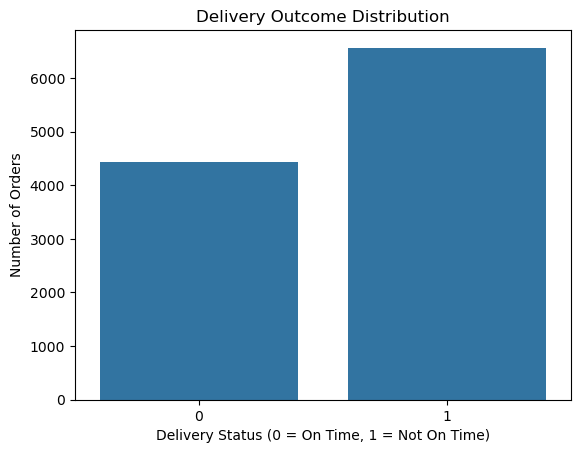

In [24]:
# Visualize the distribution of delivery outcomes
sns.countplot(x="Reached.on.Time_Y.N", data=df)

plt.title("Delivery Outcome Distribution")
plt.xlabel("Delivery Status (0 = On Time, 1 = Not On Time)")
plt.ylabel("Number of Orders")

plt.show()

### 5.2 Delivery Outcome by Shipment Mode

This visualization compares delivery outcomes across different shipment
modes to understand whether shipment mode is associated with delivery
timeliness.

In [28]:
# Load the original dataset for visualization
df_original = pd.read_excel(r"C:\Users\Lenovo\Downloads\E_Commerce.xlsx")

# Display the first five rows
df_original.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


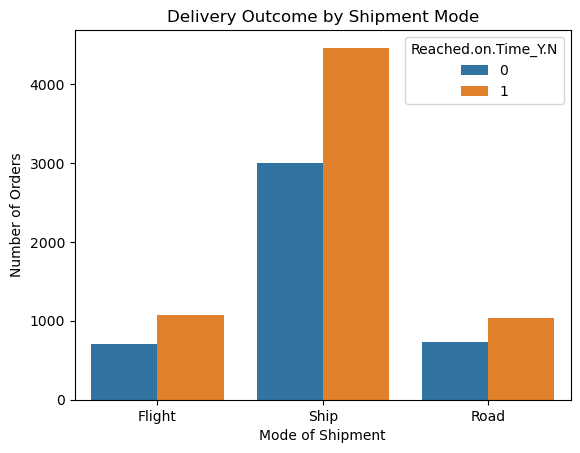

In [29]:
# Compare delivery outcomes across different shipment modes
sns.countplot(
    x="Mode_of_Shipment",
    hue="Reached.on.Time_Y.N",
    data=df_original
)

plt.title("Delivery Outcome by Shipment Mode")
plt.xlabel("Mode of Shipment")
plt.ylabel("Number of Orders")

plt.show()

### 5.3 Delivery Outcome by Warehouse

This visualization compares delivery outcomes across different warehouse blocks to understand whether warehouse location is associated with delivery timeliness.

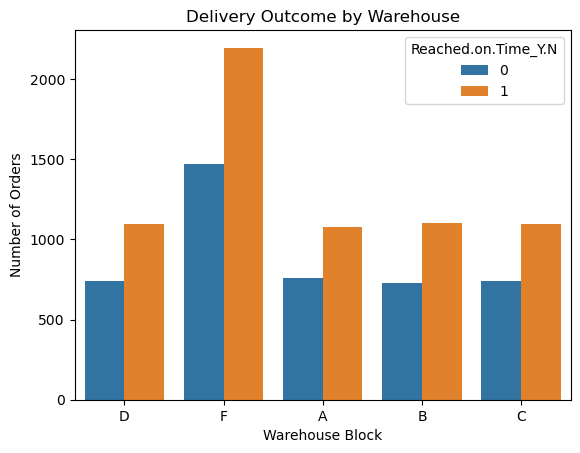

In [30]:
# Compare delivery outcomes across different warehouse blocks
sns.countplot(
    x="Warehouse_block",
    hue="Reached.on.Time_Y.N",
    data=df_original
)

plt.title("Delivery Outcome by Warehouse")
plt.xlabel("Warehouse Block")
plt.ylabel("Number of Orders")

plt.show()

### 5.4 Delivery Outcome by Product Importance

This visualization compares delivery outcomes across different product importance levels to understand whether product importance is associated with delivery timeliness.

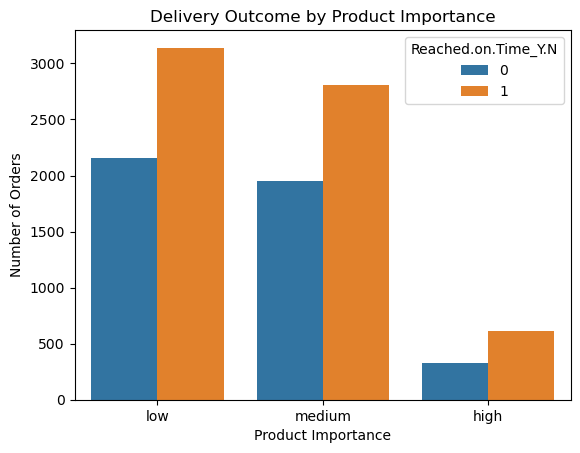

In [31]:
# Compare delivery outcomes across product importance levels
sns.countplot(
    x="Product_importance",
    hue="Reached.on.Time_Y.N",
    data=df_original
)

plt.title("Delivery Outcome by Product Importance")
plt.xlabel("Product Importance")
plt.ylabel("Number of Orders")

plt.show()

### 5.5 Correlation Heatmap

A correlation heatmap shows the relationship between numerical variables.
It helps us understand whether changes in one variable are associated
with changes in another variable.

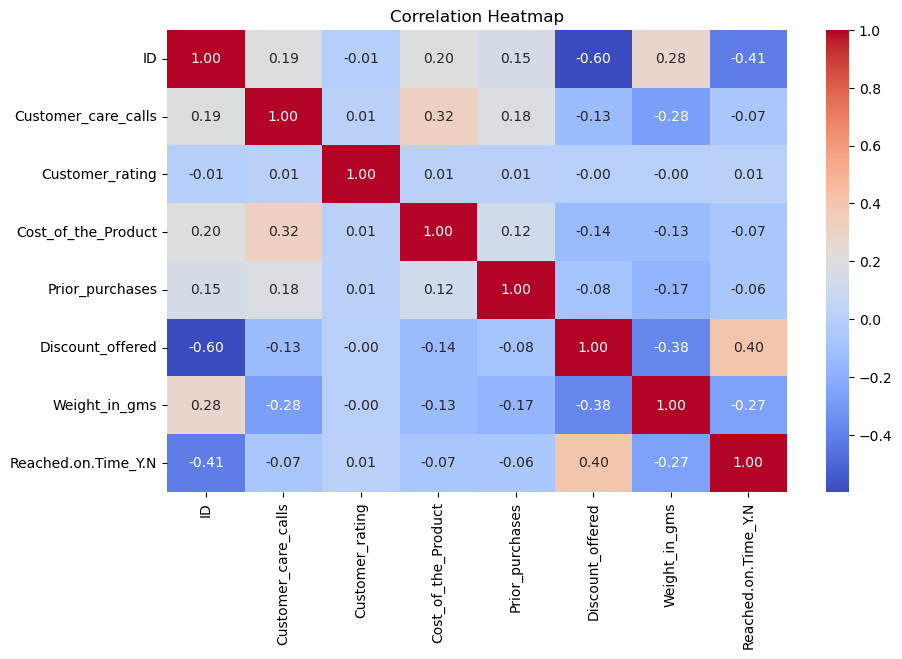

In [32]:
# Select numerical columns for correlation analysis
correlation_data = df_original.select_dtypes(include=np.number)

# Calculate correlations between numerical variables
correlation_matrix = correlation_data.corr()

# Display the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# 6. Machine Learning Algorithms

### 6.1 Preparing Features and Target

In this step, we separate the dataset into input features (X) and the target variable (y).

- X contains the features used to make predictions.
- y contains the delivery outcome that we want to predict.

In [33]:
# Separate input features and target variable

X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

# Display the shape of X and y
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10999, 15)
Target shape: (10999,)


### 6.2 Train-Test Split

The dataset is divided into training and testing sets.

The training data is used to train the machine learning models, while the testing data is used to evaluate how well the models perform on unseen data.

In [37]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)

### 6.3 Scaling the Data

Feature scaling brings the input features to a similar scale. This is especially important for models such as Logistic Regression and K-Nearest Neighbors (KNN).

In [38]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6.4 Logistic Regression

Logistic Regression is a classification model used to predict the delivery outcome of an order.

In [39]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 6.5 Decision Tree

A Decision Tree is a classification model that makes predictions by using a series of decision rules based on the input features.

In [40]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 6.6 Random Forest

Random Forest is a classification model that combines multiple Decision Trees to make a prediction.

In [41]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6.7 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a classification model that predicts the delivery outcome based on similar data points.

In [42]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn_model = KNeighborsClassifier()

# Train the model using the scaled data
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# 7. Predictive Modelling

In this section, the trained machine learning models are used to predict the delivery outcome of orders in the test dataset.

### 7.1 Making Predictions

The trained models are used to predict whether the orders in the test dataset will be delivered on time or not.

In [43]:
# Make predictions using the trained models

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_pred_tree = decision_tree_model.predict(X_test)
y_pred_forest = random_forest_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test_scaled)

# 8. Model Evaluation & Comparison

In this section, we evaluate the performance of the machine learning models using accuracy, confusion matrices, and classification reports.

### 8.1 Accuracy Comparison

Accuracy shows the percentage of predictions that were correct.

In [45]:
# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
accuracy_forest = accuracy_score(y_test, y_pred_forest)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Display the accuracy of each model
print("Logistic Regression:", accuracy_logistic)
print("Decision Tree:", accuracy_tree)
print("Random Forest:", accuracy_forest)
print("KNN:", accuracy_knn)

Logistic Regression: 0.6445454545454545
Decision Tree: 0.6427272727272727
Random Forest: 0.6627272727272727
KNN: 0.6277272727272727


### 8.2 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by a classification model.

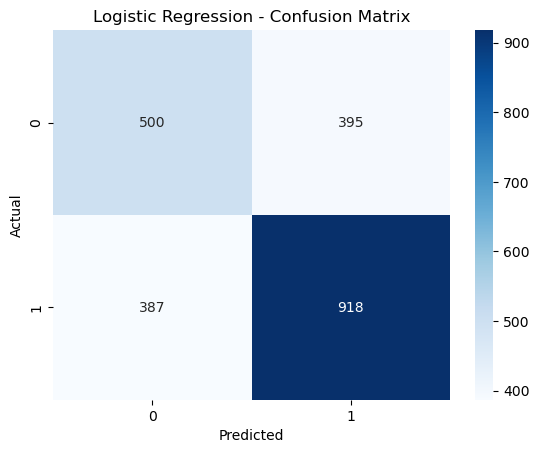

In [46]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create the confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Display the confusion matrix
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

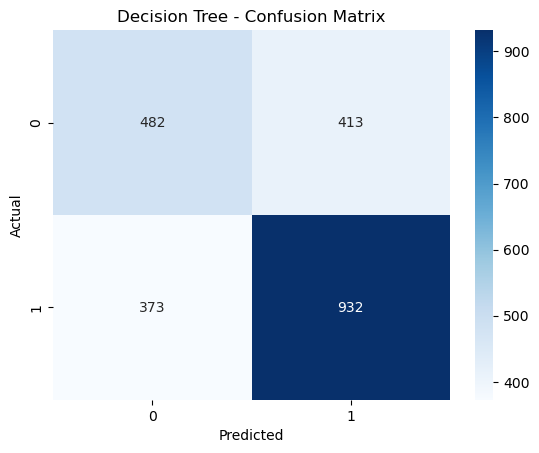

In [47]:
# Create the confusion matrix for Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Display the confusion matrix
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

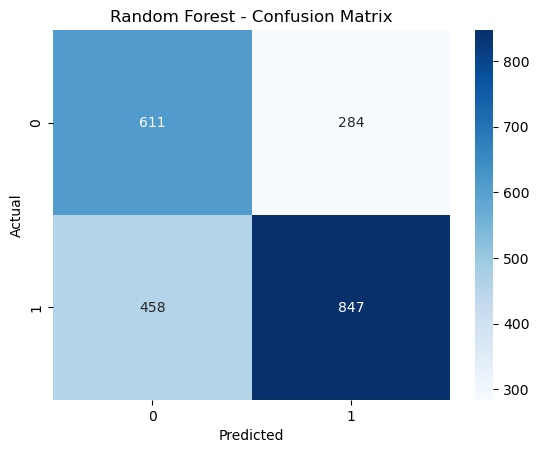

In [48]:
# Create the confusion matrix for Random Forest
cm_forest = confusion_matrix(y_test, y_pred_forest)

# Display the confusion matrix
sns.heatmap(cm_forest, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

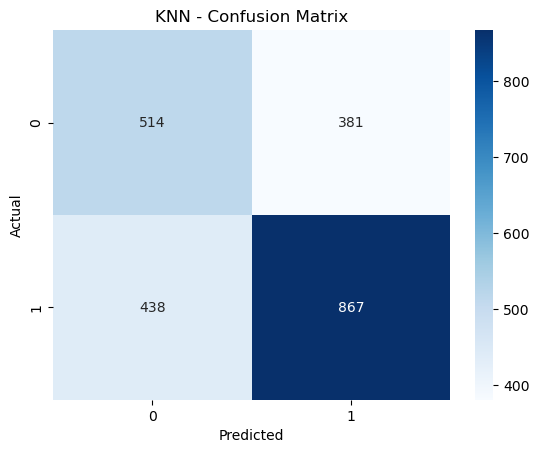

In [49]:
# Create the confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Display the confusion matrix
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 8.3 Classification Report

The classification report provides precision, recall, and F1-score for each delivery outcome class.

In [50]:
# Import classification report
from sklearn.metrics import classification_report

# Display the classification report for Logistic Regression
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.56      0.56      0.56       895
           1       0.70      0.70      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [51]:
# Display the classification report for Decision Tree
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.56      0.54      0.55       895
           1       0.69      0.71      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [52]:
# Display the classification report for Random Forest
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.57      0.68      0.62       895
           1       0.75      0.65      0.70      1305

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.67      2200



In [53]:
# Display the classification report for KNN
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.54      0.57      0.56       895
           1       0.69      0.66      0.68      1305

    accuracy                           0.63      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.63      0.63      2200



### 8.4 Model Comparison

The performance of the four classification models is compared using their accuracy scores.

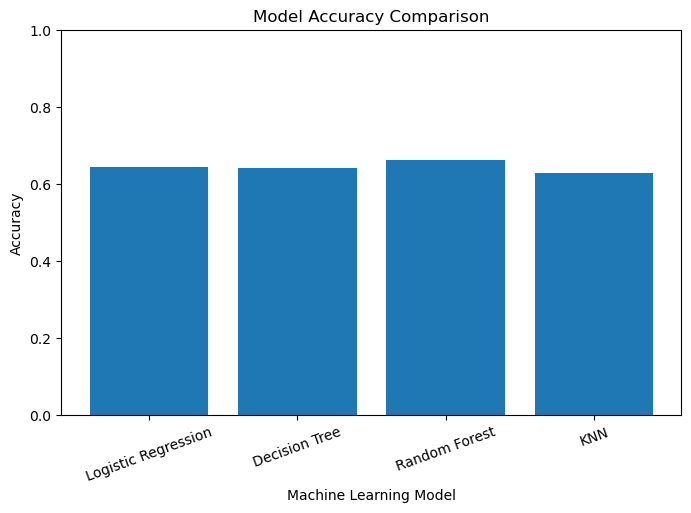

In [54]:
# Store the accuracy scores of all four models
model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "KNN"
]

accuracy_scores = [
    accuracy_logistic,
    accuracy_tree,
    accuracy_forest,
    accuracy_knn
]

# Create a bar chart to compare model accuracy
plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracy_scores)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

# 9. Feature Importance

Feature importance helps us understand which features were most important for the predictions made by the Random Forest model.

In [55]:
# Get feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Weight_in_gms,0.261913
4,Discount_offered,0.234143
2,Cost_of_the_Product,0.173602
3,Prior_purchases,0.067223
1,Customer_rating,0.062354
0,Customer_care_calls,0.060237
14,Gender_M,0.022765
11,Mode_of_Shipment_Ship,0.019106
9,Warehouse_block_F,0.017051
12,Product_importance_low,0.015047


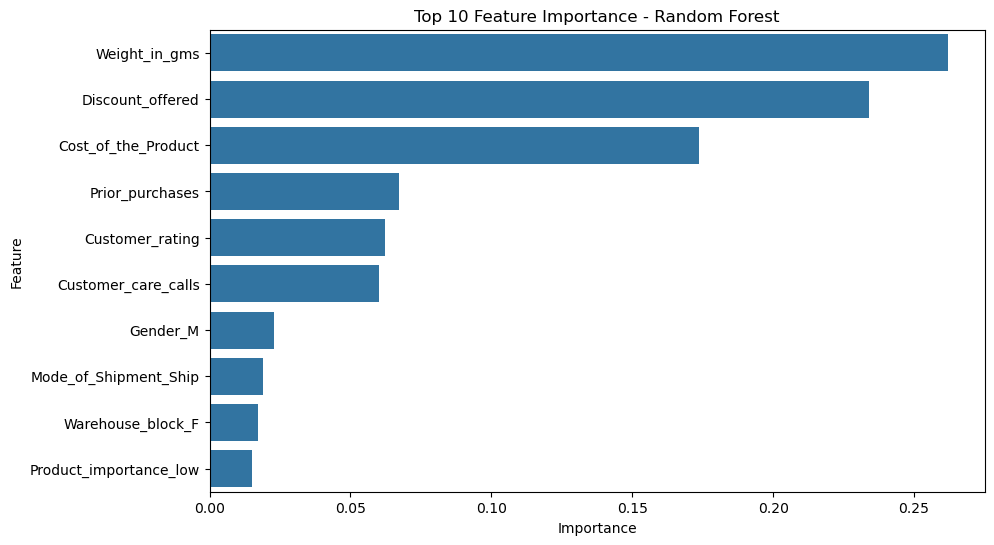

In [56]:
# Plot the top 10 important features
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 10. Business Insights

The analysis and machine learning results provide useful insights into
the factors associated with delivery outcomes. These insights can help
an e-commerce company understand delivery patterns and improve logistics
planning and customer satisfaction.

### 10.1 Key Insights

- About 59.67% of the orders in the dataset were not delivered on time, while 40.33% were delivered on time.
- Weight in grams was the most important feature used by the Random Forest model, followed by discount offered and product cost.
- Discount offered showed the strongest positive correlation with the delivery outcome among the numerical features.
- The shipment mode, warehouse block, and product importance categories showed different order volumes in the dataset.
- Random Forest achieved the highest accuracy among the four tested models, with an accuracy of 66.27%.
- Decision Tree achieved the highest recall for the delayed-delivery class, at 71%.

# 11. Conclusion

This project developed a machine learning approach to predict whether an
e-commerce order would be delivered on time or not.

The dataset was cleaned, explored, and prepared for machine learning.
Categorical variables were encoded, and the data was divided into
training and testing sets. Four classification algorithms were trained:
Logistic Regression, Decision Tree, Random Forest, and K-Nearest
Neighbors.

Among the tested models, Random Forest achieved the highest accuracy of
66.27%. The feature-importance analysis showed that Weight_in_gms,
Discount_offered, and Cost_of_the_Product were the most important
features used by the Random Forest model.

The analysis provides useful information about delivery patterns and
can help an e-commerce company better understand factors associated
with delivery outcomes and support logistics planning.

In [6]:
df.to_excel(r"C:\Users\Lenovo\Downloads\E_Commerce.xlsx", index=False)

In [9]:
df.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1
